In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


In [2]:
df = pd.read_csv('resumeID_pairs.csv', engine='python' , on_bad_lines='skip')
df.shape

(300, 4)

In [3]:
df.describe()

,match_score
count,300.000000
mean,0.550867
std,0.279331
min,-0.390000
25%,0.317500
50%,0.565000
75%,0.790000
max,1.320000


In [4]:
df.head()

,resume_text,job_description,match_label,match_score
0,BI Analyst with 7 years of experience based in...,Fathom is hiring a Financial Analyst (Berlin)....,medium,0.53
1,Data Scientist with 13 years of experience bas...,Lumen is hiring a Senior UX Designer (Singapor...,low,0.26
2,Software Engineer with 8 years of experience b...,Acme Corp is hiring a Product Manager (Seattle...,low,0.31
3,Backend Engineer with 15 years of experience b...,Umbrella Labs is hiring a Senior Data Scientis...,medium,0.46
4,Cloud Engineer with 5 years of experience base...,Cobalt is hiring a Platform Engineer (Austin)....,high,0.77


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resume_text      296 non-null    object 
 1   job_description  297 non-null    object 
 2   match_label      300 non-null    object 
 3   match_score      300 non-null    float64
dtypes: float64(1), object(3)
memory usage: 9.5+ KB


In [6]:
df.isnull().sum()

resume_text        4
job_description    3
match_label        0
match_score        0
dtype: int64

In [7]:
print("Text columns summary :")
df.describe(include='object')

Text columns summary :


,resume_text,job_description,match_label
count,296,297,300
unique,288,291,9
top,Experienced professional seeking new role.,BrightData is hiring a Senior Software Enginee...,medium
freq,3,2,102


In [8]:
row_dul = df.duplicated().sum()
print(f"row_dul.. : {row_dul}")


row_dul.. : 3


In [9]:
pair_dul = df.duplicated(subset=['resume_text', 'job_description',]).sum()
print(f"dul... resume+JD pair : {pair_dul}")

dul... resume+JD pair : 6


In [10]:
print("dul..rows :")
df[df.duplicated(subset=['resume_text', 'job_description',], keep=False)]

dul..rows :


,resume_text,job_description,match_label,match_score
35,BI Analyst with 6 years of experience based in...,Acme Corp is hiring a Data Scientist (Austin)....,medium,0.67
50,Senior UX Designer with 11 years of experience...,Fathom is hiring a UX Designer (London). In th...,HIGH,0.89
62,Site Reliability Engineer with 15 years of exp...,Acme Corp is hiring a DevOps Engineer (Bangalo...,high,0.78
70,Product Designer with 11 years of experience b...,Umbrella Labs is hiring a UX/UI Designer (New ...,high,0.93
141,Site Reliability Engineer with 15 years of exp...,Acme Corp is hiring a DevOps Engineer (Bangalo...,high,0.78
152,Backend Engineer with 14 years of experience b...,BrightData is hiring a Senior Software Enginee...,high,0.88
202,Senior Financial Analyst with 11 years of expe...,Nimbus is hiring a FP&A Analyst (New York). In...,high,0.21
218,Backend Engineer with 14 years of experience b...,BrightData is hiring a Senior Software Enginee...,high,0.86
220,Senior UX Designer with 11 years of experience...,Fathom is hiring a UX Designer (London). In th...,HIGH,0.89
226,BI Analyst with 6 years of experience based in...,Acme Corp is hiring a Data Scientist (Austin)....,medium,0.69


In [11]:
#What labels exist? (spot the case inconsistency!)
print("Unique labels found :")
print(df['match_label'].value_counts())

#Is the casing consistent?
print(f"\nExpected 3 labels, got : {df['match_label'].unique()} unique values")
print("Distinct values: ", df['match_label'].unique())

Unique labels found :
match_label
medium    102
high       87
low        66
MEDIUM     10
High        9
HIGH        7
Medium      7
LOW         6
Low         6
Name: count, dtype: int64

Expected 3 labels, got : ['medium' 'low' 'high' 'LOW' 'Low' 'MEDIUM' 'HIGH' 'Medium' 'High'] unique values
Distinct values:  ['medium' 'low' 'high' 'LOW' 'Low' 'MEDIUM' 'HIGH' 'Medium' 'High']


In [12]:
# ─── Section: Uniqueness Checks ───────────────────────────────────────────────

print(f"Total rows:          {len(df)}")
print(f"Unique resumes:      {df['resume_text'].nunique()}")
print(f"Unique JDs:          {df['job_description'].nunique()}")
print(f"Unique resume+JD pairs: {df[['resume_text','job_description']].drop_duplicates().shape[0]}")

Total rows:          300
Unique resumes:      288
Unique JDs:          291
Unique resume+JD pairs: 294


In [13]:
# ─── Section: Label Consistency ───────────────────────────────────────────────

# What labels exist? (spot the case inconsistency!)
print("Unique labels found:")
print(df['match_label'].value_counts())

# Is the casing consistent?
print(f"\nExpected 3 labels, got: {df['match_label'].nunique()} unique values")
print("Distinct values:", df['match_label'].unique())

Unique labels found:
match_label
medium    102
high       87
low        66
MEDIUM     10
High        9
HIGH        7
Medium      7
LOW         6
Low         6
Name: count, dtype: int64

Expected 3 labels, got: 9 unique values
Distinct values: ['medium' 'low' 'high' 'LOW' 'Low' 'MEDIUM' 'HIGH' 'Medium' 'High']


In [14]:
print("Score distribution:")
print(df['match_score'].describe())
print()

# Scores must be between 0.0 and 1.0 — flag the bad ones
invalid_scores = df[(df['match_score'] < 0) | (df['match_score'] > 1)]
print(f"Invalid scores (out of 0–1 range): {len(invalid_scores)}")
print(invalid_scores[['match_label', 'match_score']])

Score distribution:
count    300.000000
mean       0.550867
std        0.279331
min       -0.390000
25%        0.317500
50%        0.565000
75%        0.790000
max        1.320000
Name: match_score, dtype: float64

Invalid scores (out of 0–1 range): 4
    match_label  match_score
63       medium        -0.12
74       MEDIUM        -0.39
123        high         1.32
132      medium         1.08


In [15]:
# ─── Section: Label vs Score Sanity Check ─────────────────────────────────────
# Do scores actually match what the label says?

print("Score stats per label (after lowercasing):")
df['match_label_lower'] = df['match_label'].str.lower()
print(df.groupby('match_label_lower')['match_score'].describe().round(2))

# Expected:
#   high   → 0.75 – 0.95
#   medium → 0.40 – 0.70
#   low    → 0.05 – 0.35

Score stats per label (after lowercasing):
                   count  mean   std   min   25%   50%   75%   max
match_label_lower                                                 
high               103.0  0.83  0.16  0.06  0.79  0.87  0.90  1.32
low                 78.0  0.20  0.09  0.06  0.13  0.21  0.27  0.35
medium             119.0  0.54  0.15 -0.39  0.48  0.55  0.64  1.08


In [16]:
# ─── Section: Null Values ─────────────────────────────────────────────────────

print("Missing values per column:")
print(df.isnull().sum())
print()

# Show the rows with nulls
nulls = df[df.isnull().any(axis=1)]
print(f"Rows with at least one null: {len(nulls)}")
nulls[['match_label', 'match_score']].head(10)

Missing values per column:
resume_text          4
job_description      3
match_label          0
match_score          0
match_label_lower    0
dtype: int64

Rows with at least one null: 7


,match_label,match_score
69,low,0.20
83,medium,0.55
160,medium,0.66
163,HIGH,0.77
214,medium,0.49
256,high,0.92
262,medium,0.40


In [17]:
# ─── Summary: All issues found ────────────────────────────────────────────────

print("=" * 50)
print("DATA QUALITY REPORT — merged_dataset.csv")
print("=" * 50)
print(f"  Total rows:             {len(df)}")
print(f"  Full duplicates:        {df.duplicated().sum()}")
print(f"  Duplicate pairs:        {df.duplicated(subset=['resume_text','job_description']).sum()}")
print(f"  Null resume_text:       {df['resume_text'].isnull().sum()}")
print(f"  Null job_description:   {df['job_description'].isnull().sum()}")
print(f"  Label case variants:    {df['match_label'].nunique()} (expected 3)")
print(f"  Invalid scores (<0/>1): {((df['match_score'] < 0) | (df['match_score'] > 1)).sum()}")

DATA QUALITY REPORT — merged_dataset.csv
  Total rows:             300
  Full duplicates:        3
  Duplicate pairs:        6
  Null resume_text:       4
  Null job_description:   3
  Label case variants:    9 (expected 3)
  Invalid scores (<0/>1): 4


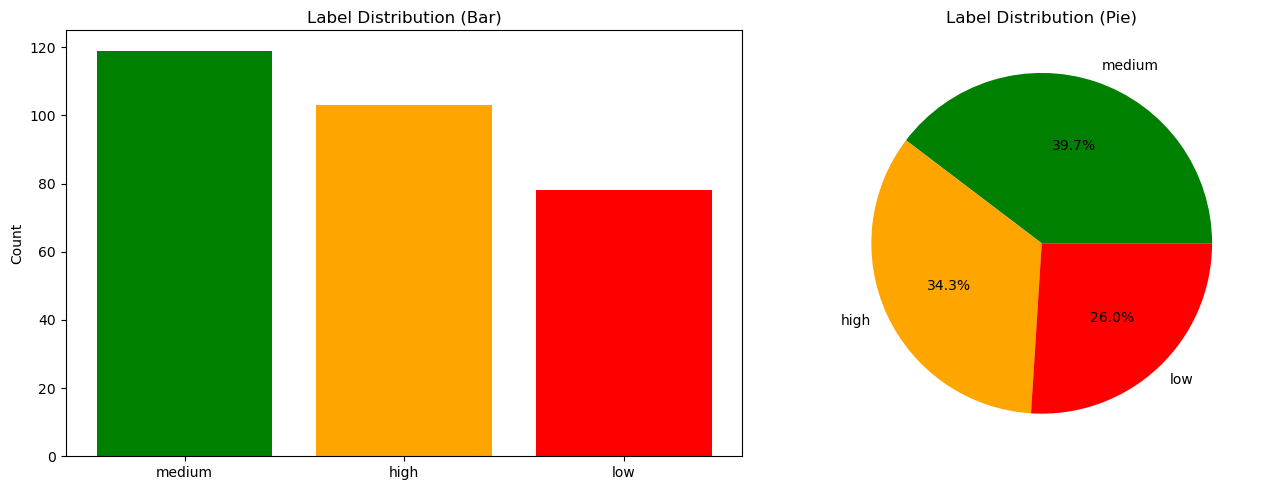

In [18]:
# Pie chart + bar side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['match_label'].str.lower().value_counts()

axes[0].bar(counts.index, counts.values, color=['green','orange','red'])
axes[0].set_title('Label Distribution (Bar)')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['green','orange','red'])
axes[1].set_title('Label Distribution (Pie)')

plt.tight_layout()
plt.show()

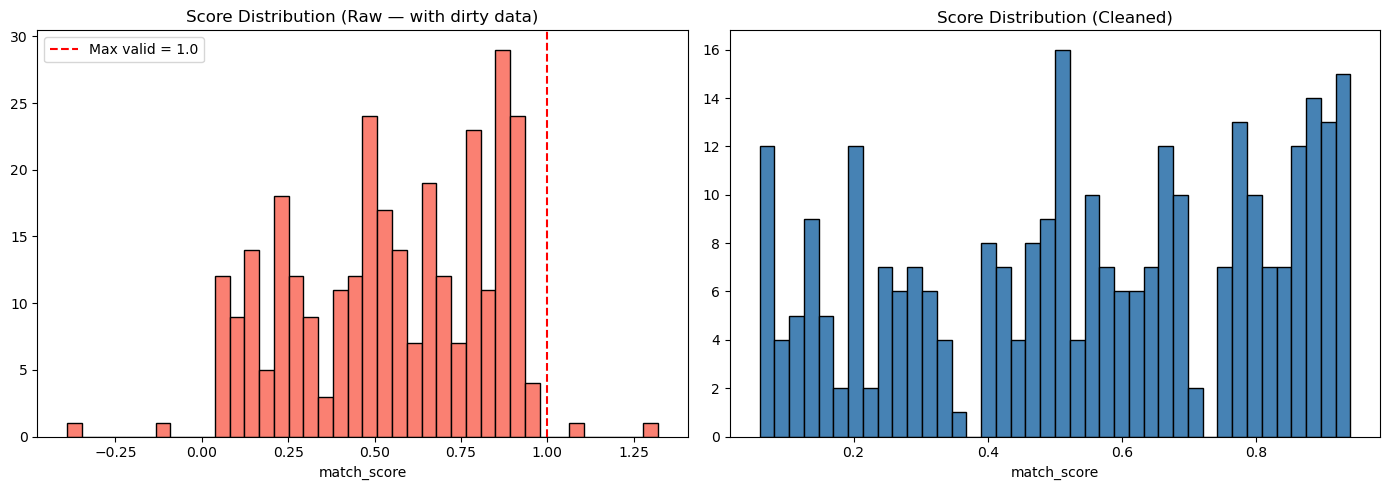

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before cleaning
axes[0].hist(df['match_score'], bins=40, color='salmon', edgecolor='black')
axes[0].set_title('Score Distribution (Raw — with dirty data)')
axes[0].set_xlabel('match_score')
axes[0].axvline(1.0, color='red', linestyle='--', label='Max valid = 1.0')
axes[0].legend()

# After cleaning
clean = df[(df['match_score'] >= 0) & (df['match_score'] <= 1)]
axes[1].hist(clean['match_score'], bins=40, color='steelblue', edgecolor='black')
axes[1].set_title('Score Distribution (Cleaned)')
axes[1].set_xlabel('match_score')

plt.tight_layout()
plt.show()

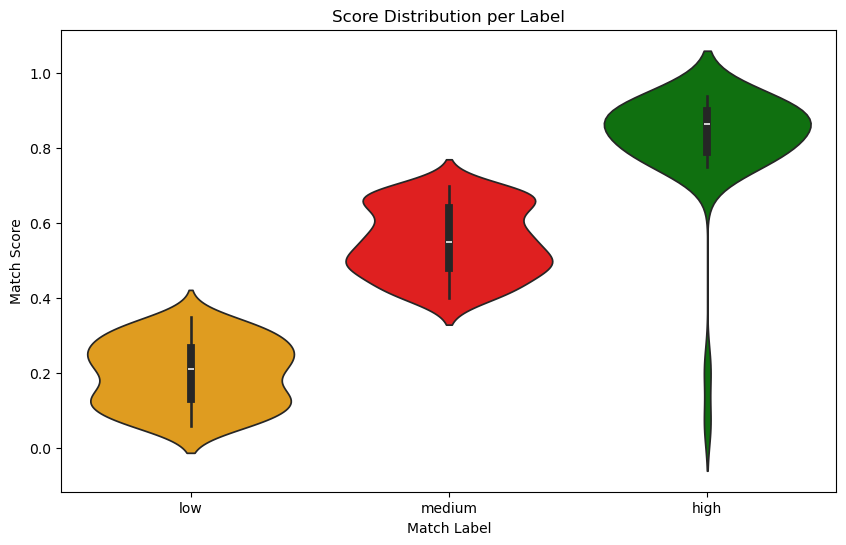

In [20]:
import seaborn as sns

df_plot = df.copy()
df_plot['match_label'] = df_plot['match_label'].str.lower()
df_plot = df_plot[(df_plot['match_score'] >= 0) & (df_plot['match_score'] <= 1)]

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_plot, x='match_label', y='match_score',
               order=['low','medium','high'],
               hue='match_label', palette=['red','orange','green'], legend=False)
plt.title('Score Distribution per Label')
plt.xlabel('Match Label')
plt.ylabel('Match Score')
plt.show()

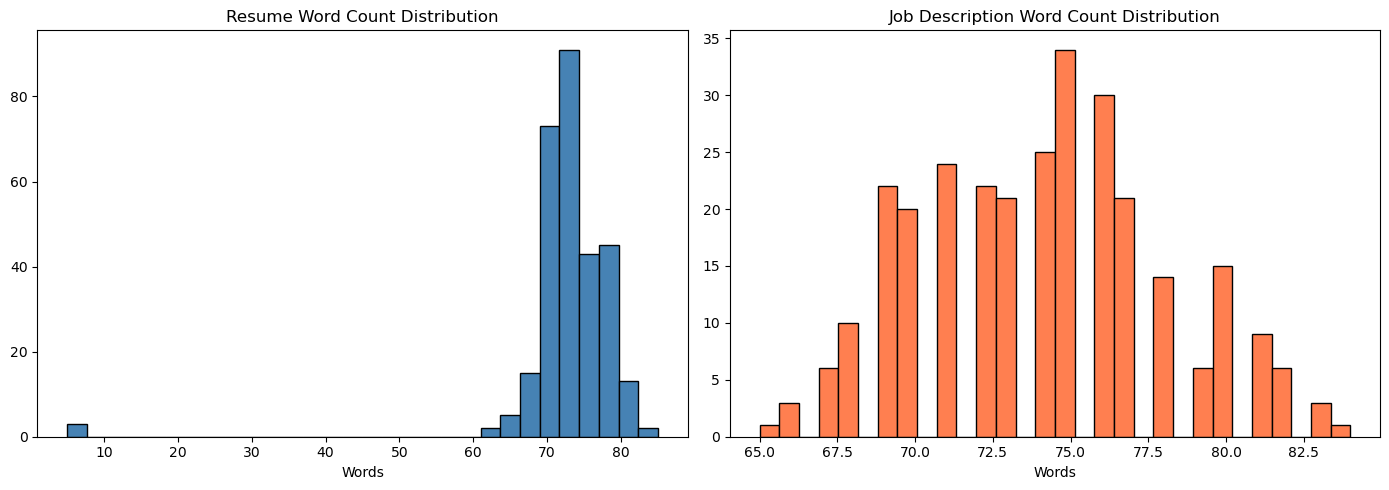

In [21]:
df_plot['resume_len'] = df_plot['resume_text'].str.split().str.len()
df_plot['jd_len']     = df_plot['job_description'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_plot['resume_len'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Resume Word Count Distribution')
axes[0].set_xlabel('Words')

axes[1].hist(df_plot['jd_len'], bins=30, color='coral', edgecolor='black')
axes[1].set_title('Job Description Word Count Distribution')
axes[1].set_xlabel('Words')

plt.tight_layout()
plt.show()

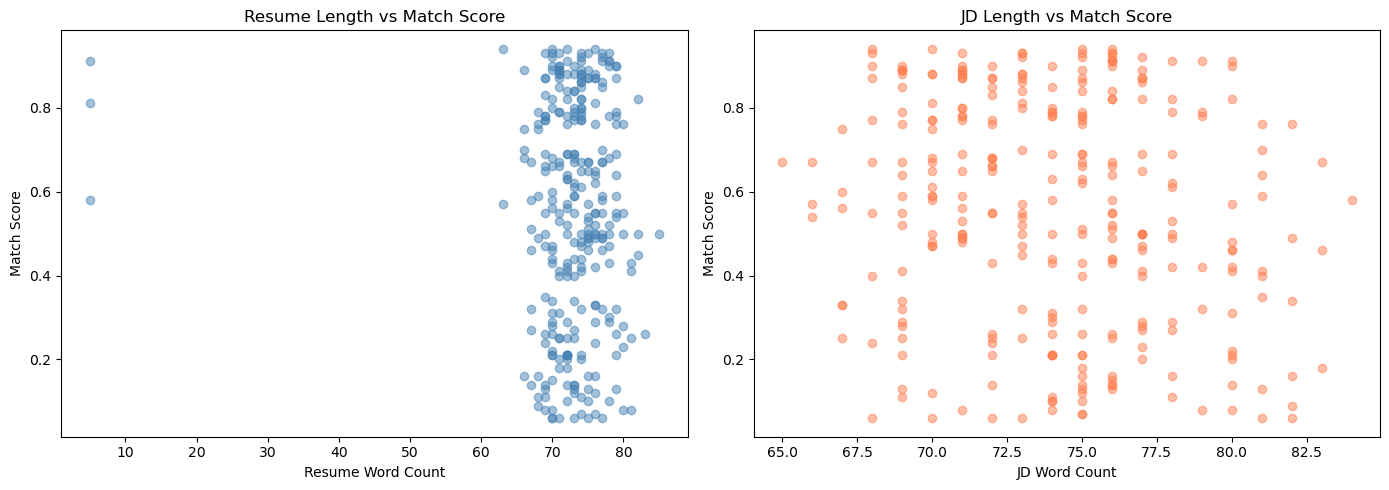

Resume length correlation: -0.07
JD length correlation:     -0.172


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_plot['resume_len'], df_plot['match_score'], alpha=0.5, color='steelblue')
axes[0].set_xlabel('Resume Word Count')
axes[0].set_ylabel('Match Score')
axes[0].set_title('Resume Length vs Match Score')

axes[1].scatter(df_plot['jd_len'], df_plot['match_score'], alpha=0.5, color='coral')
axes[1].set_xlabel('JD Word Count')
axes[1].set_ylabel('Match Score')
axes[1].set_title('JD Length vs Match Score')

plt.tight_layout()
plt.show()

# Actual correlation values
print("Resume length correlation:", df_plot['resume_len'].corr(df_plot['match_score']).round(3))
print("JD length correlation:    ", df_plot['jd_len'].corr(df_plot['match_score']).round(3))

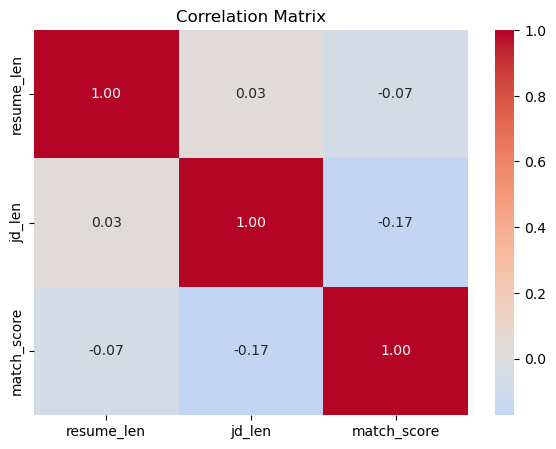

In [23]:
plt.figure(figsize=(7, 5))
corr = df_plot[['resume_len', 'jd_len', 'match_score']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [24]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


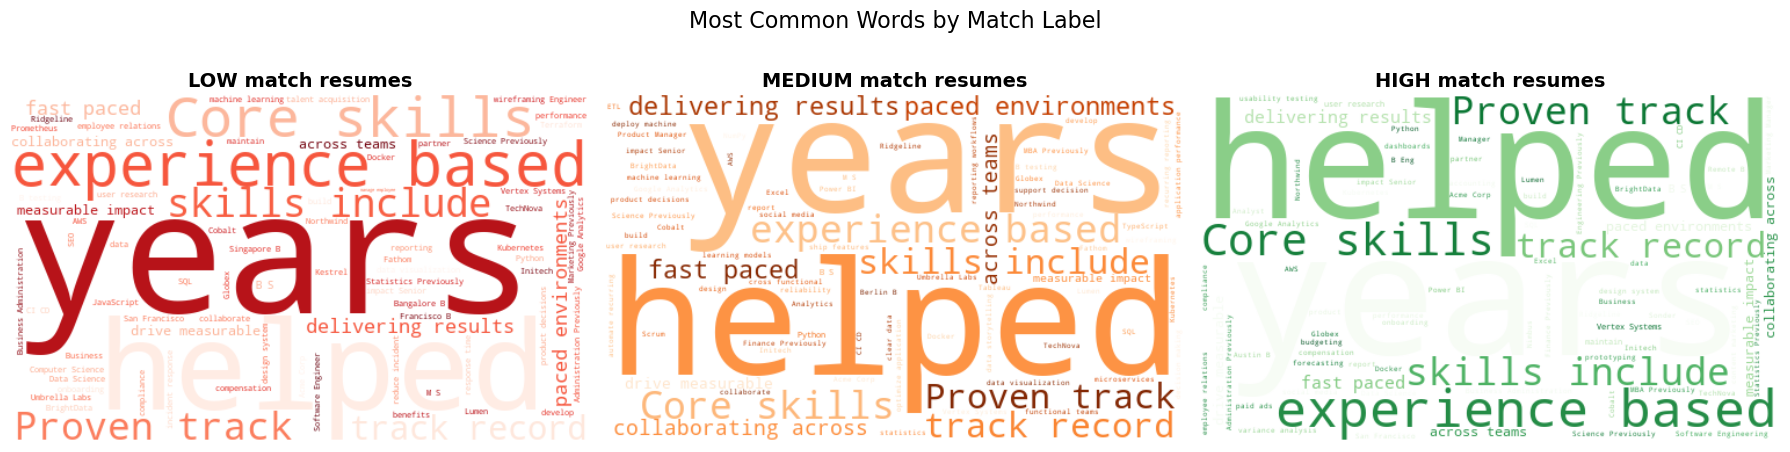

In [25]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels  = ['low', 'medium', 'high']
colors  = ['Reds', 'Oranges', 'Greens']

for ax, label, cmap in zip(axes, labels, colors):
    text = ' '.join(df_plot[df_plot['match_label'] == label]['resume_text'].dropna())
    wc = WordCloud(width=500, height=300, background_color='white',
                   colormap=cmap, max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label.upper()} match resumes', fontsize=14, fontweight='bold')

plt.suptitle('Most Common Words by Match Label', fontsize=16)
plt.tight_layout()
plt.show()

In [26]:
# Always record the starting point so that you  can see what changed
print("BEFORE CLEANING")
print("=" * 40)
print(f"Total rows:       {len(df)}")
print(f"Null resume_text: {df['resume_text'].isnull().sum()}")
print(f"Null job_desc:    {df['job_description'].isnull().sum()}")
print(f"Duplicates:       {df.duplicated().sum()}")
print(f"Label variants:   {df['match_label'].nunique()}")
print(f"Invalid scores:   {((df['match_score'] < 0) | (df['match_score'] > 1)).sum()}")

df_clean = df.copy()

BEFORE CLEANING
Total rows:       300
Null resume_text: 4
Null job_desc:    3
Duplicates:       3
Label variants:   9
Invalid scores:   4


In [27]:
# Problem: 'high', 'High', 'HIGH' are treated as 3 different categories
print("Before:", df_clean['match_label'].value_counts().to_dict())

df_clean['match_label'] = df_clean['match_label'].str.lower().str.strip()

print("After: ", df_clean['match_label'].value_counts().to_dict())
print(f"\nUnique labels now: {df_clean['match_label'].nunique()} (expected 3)")

Before: {'medium': 102, 'high': 87, 'low': 66, 'MEDIUM': 10, 'High': 9, 'HIGH': 7, 'Medium': 7, 'LOW': 6, 'Low': 6}
After:  {'medium': 119, 'high': 103, 'low': 78}

Unique labels now: 3 (expected 3)


In [28]:
print(f"Before dropping nulls: {len(df_clean)} rows")

df_clean = df_clean.dropna(subset=['resume_text', 'job_description'])

print(f"After dropping nulls:  {len(df_clean)} rows")
print(f"Removed: {len(df) - len(df_clean)} rows")

Before dropping nulls: 300 rows
After dropping nulls:  293 rows
Removed: 7 rows


In [29]:
print(f"Before removing duplicates: {len(df_clean)} rows")
print(f"Duplicate pairs found: {df_clean.duplicated(subset=['resume_text','job_description']).sum()}")

df_clean = df_clean.drop_duplicates(subset=['resume_text', 'job_description'], keep='first')

print(f"After removing duplicates:  {len(df_clean)} rows")

Before removing duplicates: 293 rows
Duplicate pairs found: 6
After removing duplicates:  287 rows


In [30]:
# Scores must be in [0.0, 1.0], anything else is a data error
invalid_mask = (df_clean['match_score'] < 0.0) | (df_clean['match_score'] > 1.0)
print(f"Invalid scores found: {invalid_mask.sum()}")
print(df_clean[invalid_mask][['match_label','match_score']])

df_clean = df_clean[~invalid_mask]
print(f"\nRows after removing invalid scores: {len(df_clean)}")

Invalid scores found: 4
    match_label  match_score
63       medium        -0.12
74       medium        -0.39
123        high         1.32
132      medium         1.08

Rows after removing invalid scores: 283


In [31]:
#are the scores consistent with what the label claims?
# Expected: low=0.05-0.35, medium=0.40-0.70, high=0.75-0.95

print("Score range per label:")
print(df_clean.groupby('match_label')['match_score'].agg(['min','max','mean']).round(2))

# Flag any rows where label and score contradict each other
def label_score_mismatch(row):
    score = row['match_score']
    label = row['match_label']
    if label == 'high'   and score < 0.70: return True
    if label == 'medium' and (score < 0.35 or score > 0.75): return True
    if label == 'low'    and score > 0.40: return True
    return False

mismatches = df_clean.apply(label_score_mismatch, axis=1)
print(f"\nLabel-score mismatches: {mismatches.sum()}")
df_clean[mismatches][['match_label','match_score']]

Score range per label:
              min   max  mean
match_label                  
high         0.06  0.94  0.83
low          0.06  0.35  0.20
medium       0.40  0.70  0.55

Label-score mismatches: 3


,match_label,match_score
54,high,0.06
202,high,0.21
239,high,0.07


In [32]:
# A 15-character resume or JD is useless for training
df_clean['resume_len'] = df_clean['resume_text'].str.split().str.len()
df_clean['jd_len']     = df_clean['job_description'].str.split().str.len()

print("Short texts found:")
print(f"  resume_text < 20 words: {(df_clean['resume_len'] < 20).sum()}")
print(f"  job_description < 10 words: {(df_clean['jd_len'] < 10).sum()}")

df_clean = df_clean[(df_clean['resume_len'] >= 20) & (df_clean['jd_len'] >= 10)]
print(f"\nRows after removing short texts: {len(df_clean)}")

Short texts found:
  resume_text < 20 words: 3
  job_description < 10 words: 0

Rows after removing short texts: 280


In [33]:
df_clean = df_clean.reset_index(drop=True)

print("=" * 45)
print("CLEANING SUMMARY")
print("=" * 45)
print(f"  Original rows:        {len(df)}")
print(f"  Final rows:           {len(df_clean)}")
print(f"  Rows removed:         {len(df) - len(df_clean)}")
print()
print(f"  Nulls remaining:      {df_clean.isnull().sum().sum()}")
print(f"  Duplicates remaining: {df_clean.duplicated().sum()}")
print(f"  Label variants:       {df_clean['match_label'].nunique()}")
print(f"  Score range:          {df_clean['match_score'].min()} – {df_clean['match_score'].max()}")
print()
print("Label distribution after cleaning:")
print(df_clean['match_label'].value_counts())
print("=" * 45)

CLEANING SUMMARY
  Original rows:        300
  Final rows:           280
  Rows removed:         20

  Nulls remaining:      0
  Duplicates remaining: 0
  Label variants:       3
  Score range:          0.06 – 0.94

Label distribution after cleaning:
match_label
medium    110
high       93
low        77
Name: count, dtype: int64


In [35]:
# Drop the helper columns we added during EDA
df_clean.to_csv('cleaned_resumeJD_pairs.csv', index=False)
print(f"Saved: dataset/cleaned_resumeJD_pairs.csv ({len(df_clean)} rows)")

Saved: dataset/cleaned_resumeJD_pairs.csv (280 rows)
